# CardioIA — Fase 1 | Exploração e Auditoria das Bases

Notebook de verificação das três bases entregues:

1. **Parte 1** — coorte numérica (`data/cardioia_pacientes.csv`)
2. **Parte 2** — corpus textual (`docs/*.txt`)
3. **Parte 3** — imagens de ECG (`assets/ecg/`)

Além da EDA tradicional, este notebook roda a **auditoria de viés** descrita em
`docs/GOVERNANCA_DE_DADOS.md`. Rode as células na ordem.

In [1]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
df = pd.read_csv(os.path.join(BASE, "data", "cardioia_pacientes.csv"))
print(df.shape)
df.head()

(800, 33)


,id_paciente,idade,sexo,regiao_atendimento,imc,tabagismo,etilismo,diabetes,hipertensao_diagnosticada,historico_familiar_dac,...,palpitacoes,sincope,edema_mmii,fadiga,classe_funcional_nyha,ecg_repouso,tempo_ate_atendimento_min,escore_risco_10a_pct,risco_cardiovascular,evento_cardiaco_12m
0,CARD-0001,70,F,Regiao Metropolitana,36.0,0,0,1,1,1,...,0,0,0,0,IV,Fibrilacao_atrial,50,77.4,Alto,1
1,CARD-0002,72,F,Capital,25.6,0,0,0,1,0,...,0,0,0,0,II,Normal,31,10.5,Intermediario,0
2,CARD-0003,59,F,Capital,27.6,0,0,0,1,1,...,0,1,0,1,II,Normal,13,12.2,Intermediario,1
3,CARD-0004,58,M,Capital,34.6,1,0,1,1,0,...,0,0,0,1,IV,Fibrilacao_atrial,27,79.0,Alto,1
4,CARD-0005,62,F,Interior,30.2,0,1,0,0,1,...,0,0,0,1,II,Normal,88,18.4,Intermediario,0


## 1. Parte 1 — Coorte numérica

### 1.1 Estrutura e tipos

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_paciente                  800 non-null    object 
 1   idade                        800 non-null    int64  
 2   sexo                         800 non-null    object 
 3   regiao_atendimento           800 non-null    object 
 4   imc                          752 non-null    float64
 5   tabagismo                    800 non-null    int64  
 6   etilismo                     800 non-null    int64  
 7   diabetes                     800 non-null    int64  
 8   hipertensao_diagnosticada    800 non-null    int64  
 9   historico_familiar_dac       800 non-null    int64  
 10  dias_ativos_semana           800 non-null    int64  
 11  pressao_sistolica            800 non-null    int64  
 12  pressao_diastolica           800 non-null    int64  
 13  frequencia_cardiaca_

In [3]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
idade,800.0,57.7,13.3,29.0,48.0,57.0,67.0,92.0
imc,752.0,27.5,4.5,16.5,24.4,27.6,30.3,40.4
tabagismo,800.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0
etilismo,800.0,0.5,0.7,0.0,0.0,0.0,1.0,2.0
diabetes,800.0,0.3,0.4,0.0,0.0,0.0,1.0,1.0
hipertensao_diagnosticada,800.0,0.4,0.5,0.0,0.0,0.0,1.0,1.0
historico_familiar_dac,800.0,0.3,0.5,0.0,0.0,0.0,1.0,1.0
dias_ativos_semana,800.0,3.5,2.3,0.0,2.0,4.0,5.0,7.0
pressao_sistolica,800.0,131.1,17.4,88.0,118.0,129.0,145.0,179.0
pressao_diastolica,800.0,84.5,11.5,54.0,76.0,85.0,93.0,119.0


### 1.2 Dados ausentes — o padrão NÃO é aleatório

A ausência de exames laboratoriais é concentrada em Interior e Zona Rural.
Imputar pela média apagaria essa informação de desigualdade de acesso.

In [4]:
faltas = df.isna().sum()
print(faltas[faltas > 0], "\n")

(df.assign(_falta=df[["colesterol_hdl","triglicerides","glicemia_jejum","imc"]].isna().any(axis=1))
   .groupby("regiao_atendimento")._falta.mean().mul(100).round(1)
   .rename("% pacientes com algum exame faltante"))

imc               48
colesterol_hdl    52
triglicerides     47
glicemia_jejum    52
dtype: int64 



regiao_atendimento
Capital                 13.6
Interior                37.5
Regiao Metropolitana    14.6
Zona Rural              43.1
Name: % pacientes com algum exame faltante, dtype: float64

### 1.3 Distribuições clínicas

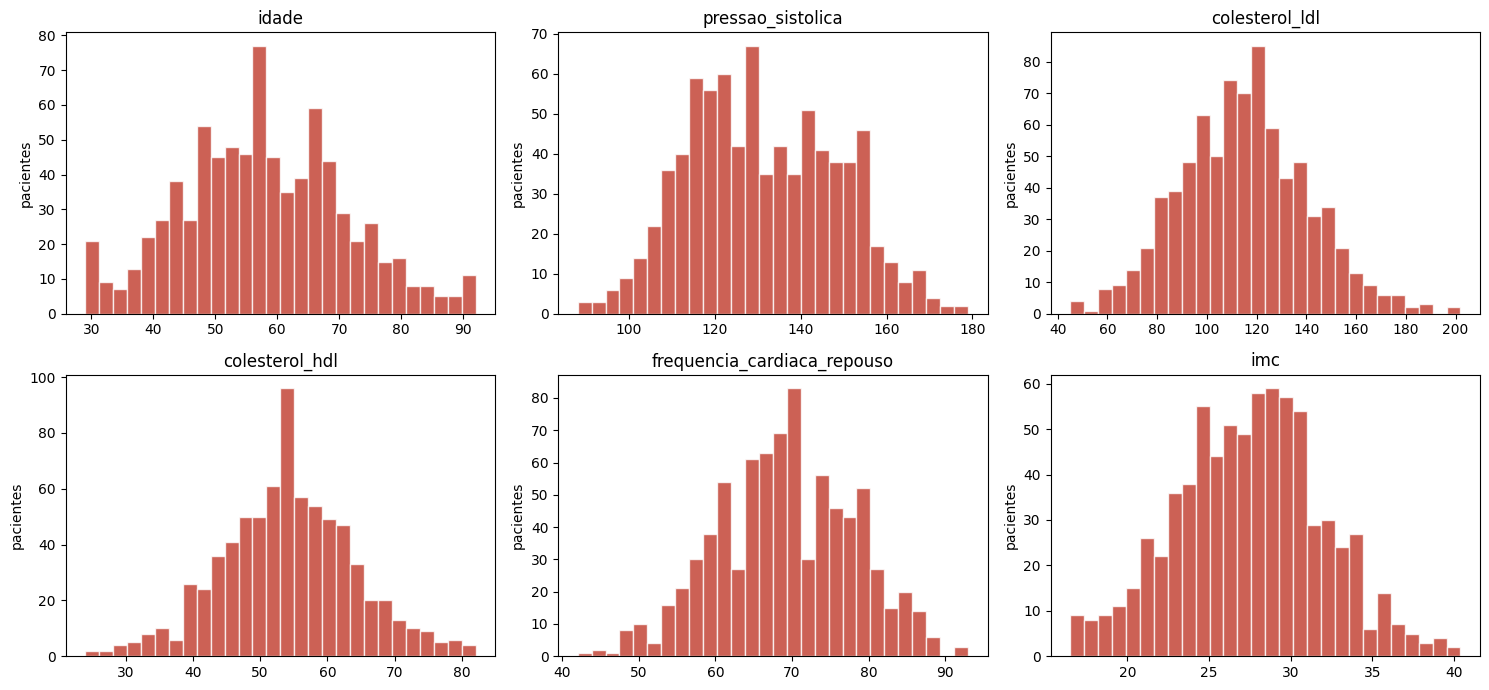

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, col in zip(ax.ravel(), ["idade","pressao_sistolica","colesterol_ldl",
                               "colesterol_hdl","frequencia_cardiaca_repouso","imc"]):
    a.hist(df[col].dropna(), bins=28, color="#c0392b", alpha=.8, edgecolor="white")
    a.set_title(col); a.set_ylabel("pacientes")
plt.tight_layout(); plt.show()

### 1.4 Correlação com o desfecho

Teste de sanidade: o **HDL deve aparecer com correlação negativa** (é protetor).
Se aparecer positivo, há erro de sinal ou vazamento.

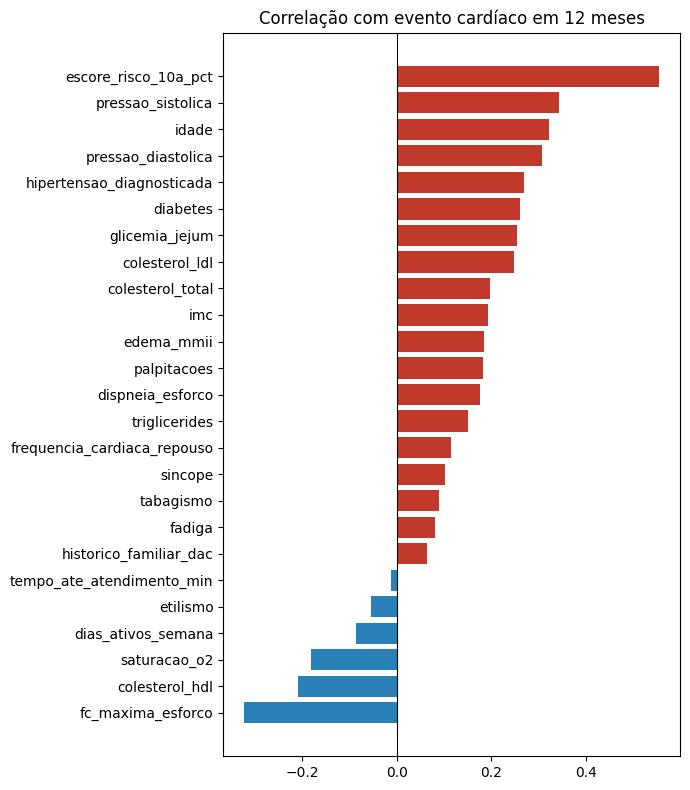

HDL: -0.21 (esperado: negativo)


In [6]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()["evento_cardiaco_12m"].drop("evento_cardiaco_12m").sort_values()
fig, ax = plt.subplots(figsize=(7, 8))
cores = ["#2980b9" if v < 0 else "#c0392b" for v in corr]
ax.barh(corr.index, corr.values, color=cores)
ax.axvline(0, color="k", lw=.8)
ax.set_title("Correlação com evento cardíaco em 12 meses")
plt.tight_layout(); plt.show()
print("HDL:", round(corr['colesterol_hdl'], 3), "(esperado: negativo)")

## 2. Auditoria de viés

Cada bloco abaixo corresponde a uma seção de `docs/GOVERNANCA_DE_DADOS.md`.

### 2.1 Viés de sexo (§3.1)

In [7]:
print(df.sexo.value_counts(normalize=True).mul(100).round(1), "\n")
print("Evento por sexo (%):")
print(df.groupby("sexo").evento_cardiaco_12m.mean().mul(100).round(1), "\n")
print("Tipo de dor torácica por sexo (% da linha):")
print(pd.crosstab(df.sexo, df.dor_toracica_tipo, normalize="index").mul(100).round(1))

sexo
M    57.0
F    43.0
Name: proportion, dtype: float64 

Evento por sexo (%):
sexo
F    13.1
M    21.7
Name: evento_cardiaco_12m, dtype: float64 

Tipo de dor torácica por sexo (% da linha):
dor_toracica_tipo  Assintomatico  Atipica  Nao_anginosa  Tipica_anginosa
sexo                                                                    
F                           16.9     34.6          27.3             21.2
M                           16.0     24.3          20.4             39.3


> **Leitura:** mulheres concentram mais dor **atípica**. Um modelo treinado sem
> atenção a isso tende a ter *recall* menor no grupo feminino — exatamente o
> subdiagnóstico documentado na literatura. Métrica a monitorar na Fase 2:
> recall por sexo, não acurácia global.

### 2.2 Viés geográfico de acesso (§3.2)

In [8]:
(df.groupby("regiao_atendimento")
   .agg(pacientes=("id_paciente","count"),
        tempo_mediano_min=("tempo_ate_atendimento_min","median"),
        evento_pct=("evento_cardiaco_12m", lambda s: round(s.mean()*100,1)))
   .sort_values("tempo_mediano_min"))

,pacientes,tempo_mediano_min,evento_pct
regiao_atendimento,,,
Capital,346,25.0,19.4
Regiao Metropolitana,205,42.0,16.1
Interior,184,68.5,16.3
Zona Rural,65,108.0,21.5


> **Armadilha:** se `tempo_ate_atendimento_min` entrar como *feature* de
> diagnóstico, o modelo pode aprender "mora longe = pior desfecho" e passar a
> desqualificar pacientes rurais. Tratar como variável de **auditoria**, não de
> predição.

### 2.3 Desbalanceamento de classe (§3.4)

In [9]:
prev = df.evento_cardiaco_12m.mean()
print(f"Prevalência de evento: {prev:.1%}")
print(f"Acurácia de um modelo que prevê SEMPRE 'sem evento': {1-prev:.1%}  <-- métrica enganosa")
print("\nUsar recall, F1 e AUC-PR nas próximas fases.\n")
print(df.risco_cardiovascular.value_counts(normalize=True).mul(100).round(1))

Prevalência de evento: 18.0%
Acurácia de um modelo que prevê SEMPRE 'sem evento': 82.0%  <-- métrica enganosa

Usar recall, F1 e AUC-PR nas próximas fases.

risco_cardiovascular
Intermediario    35.9
Alto             35.1
Baixo            29.0
Name: proportion, dtype: float64


## 3. Parte 2 — Corpus textual

In [10]:
docs = sorted(glob.glob(os.path.join(BASE, "docs", "*.txt")))
for d in docs:
    t = open(d, encoding="utf-8").read()
    print(f"{os.path.basename(d):55s} {len(t.split()):>7,} palavras  {len(set(t.lower().split())):>6,} únicas")

texto_01_harvey_1628_de_motu_cordis.txt                  20,036 palavras   4,482 únicas
texto_02_huxley_1878_descoberta_da_circulacao.txt         7,971 palavras   1,958 únicas
texto_03_prontuarios_sinteticos_cardioia.txt             45,175 palavras   1,514 únicas
texto_04_teleatendimento_dialogos_cardioia.txt           10,432 palavras     832 únicas


### 3.1 Termos cardiológicos mais frequentes nos prontuários

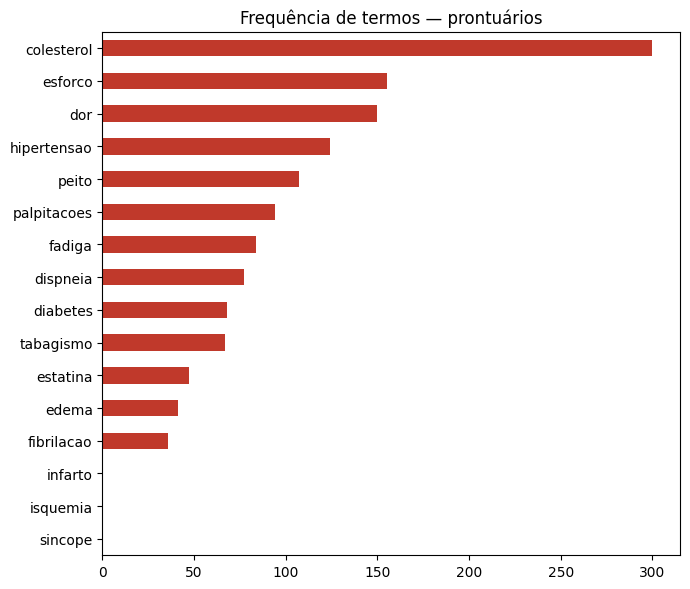

In [11]:
pront = open(os.path.join(BASE,"docs","texto_03_prontuarios_sinteticos_cardioia.txt"), encoding="utf-8").read().lower()
termos = ["dor","peito","esforco","dispneia","palpitacoes","sincope","edema",
          "fadiga","hipertensao","diabetes","tabagismo","colesterol","infarto",
          "fibrilacao","isquemia","estatina"]
freq = pd.Series({t: len(re.findall(rf"\b{t}", pront)) for t in termos}).sort_values()
freq.plot(kind="barh", figsize=(7,6), color="#c0392b", title="Frequência de termos — prontuários")
plt.tight_layout(); plt.show()

### 3.2 Corpus de teleatendimento — rótulos para NLP supervisionado

In [12]:
tel = pd.read_csv(os.path.join(BASE, "data", "corpus_teleatendimento.csv"))
print(tel.intencao.value_counts(), "\n")
print(pd.crosstab(tel.urgencia, tel.sentimento))

intencao
sintoma_emergencia      30
monitoramento           30
adesao_habitos          20
duvida_medicacao        20
apoio_emocional         20
acesso_tratamento       20
agendamento             10
efeito_adverso          10
orientacao_atividade    10
orientacao_dieta        10
sintoma_leve            10
duvida_exame            10
Name: count, dtype: int64 

sentimento  ansioso  negativo  neutro  positivo  preocupado
urgencia                                                   
alta              0        30       0         0          10
baixa             0         0      40        30           0
critica           0        10       0         0           0
media            30        20       0         0          30


### 3.3 Validação do alinhamento multimodal

Prova de que o prontuário descreve **o mesmo paciente** da linha do CSV —
o diferencial da entrega.

In [13]:
ids_pront = set(re.findall(r"PRONTUARIO (CARD-\d{4})", pront.upper()))
print(f"IDs distintos nos prontuários: {len(ids_pront)}")
print(f"Todos existem no CSV? {ids_pront.issubset(set(df.id_paciente))}")

alvo = sorted(ids_pront)[0]
print(f"\n--- linha do CSV para {alvo} ---")
print(df[df.id_paciente == alvo][["idade","sexo","pressao_sistolica",
      "frequencia_cardiaca_repouso","ecg_repouso","risco_cardiovascular"]].to_string(index=False))
i = pront.upper().find(f"PRONTUARIO {alvo}")
print(f"\n--- trecho do prontuário ---\n{open(os.path.join(BASE,'docs','texto_03_prontuarios_sinteticos_cardioia.txt'), encoding='utf-8').read()[i:i+700]}")

IDs distintos nos prontuários: 300
Todos existem no CSV? True

--- linha do CSV para CARD-0003 ---
 idade sexo  pressao_sistolica  frequencia_cardiaca_repouso ecg_repouso risco_cardiovascular
    59    F                153                           48      Normal        Intermediario

--- trecho do prontuário ---
PRONTUARIO CARD-0003 | Ambulatorio de Cardiologia - Hospital CardioIA (SIMULADO) ===
IDENTIFICACAO: Paciente do sexo feminino, 59 anos, procedente de Capital.
QUEIXA PRINCIPAL: Refere queimacao no estomago associada a nausea e falta de ar.
HISTORIA DA DOENCA ATUAL: Quadro com evolucao progressiva. Ao interrogatorio, episodio sincopal, fadiga. Classe funcional NYHA II.
ANTECEDENTES PESSOAIS: hipertensao arterial sistemica; historia familiar de doenca arterial coronariana.
HABITOS DE VIDA: pratica atividade fisica em 5 dia(s) por semana.
EXAME FISICO: PA 153x95 mmHg; FC 48 bpm; SatO2 95%; IMC 27.6 kg/m2.
EXAMES COMPLEMENTARES: colesterol total 236 mg/dL; LDL 142 mg/dL; HDL 59 mg

## 4. Parte 3 — Imagens de ECG

In [14]:
lab = pd.read_csv(os.path.join(BASE, "data", "ecg_labels.csv"))
print(lab.classe.value_counts(), "\n")
print(lab.groupby("classe").fc_estimada_bpm.agg(["mean","min","max"]).round(1))

classe
normal                 20
taquicardia_sinusal    20
bradicardia_sinusal    20
fibrilacao_atrial      20
isquemia_infra_st      20
iam_supra_st           20
Name: count, dtype: int64 

                      mean  min  max
classe                              
bradicardia_sinusal   46.2   38   52
fibrilacao_atrial    106.0   75  141
iam_supra_st          90.1   69  106
isquemia_infra_st     74.5   63   96
normal                75.4   62   89
taquicardia_sinusal  132.0  102  155


### 4.1 Amostra visual — uma imagem por classe

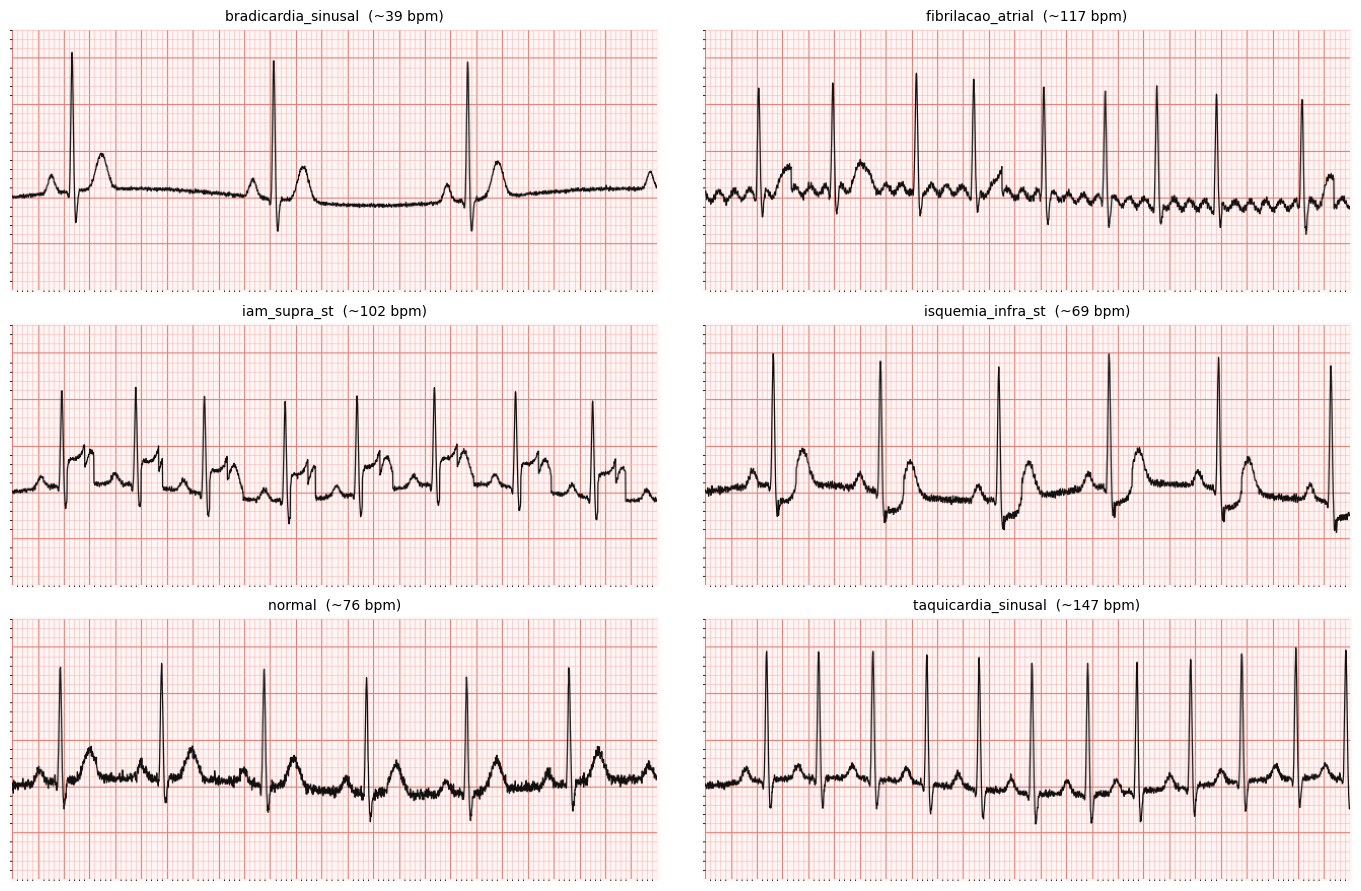

In [15]:
import matplotlib.image as mpimg
fig, ax = plt.subplots(3, 2, figsize=(14, 9))
for a, (classe, g) in zip(ax.ravel(), lab.groupby("classe")):
    a.imshow(mpimg.imread(os.path.join(BASE, g.arquivo.iloc[0])))
    a.set_title(f"{classe}  (~{int(g.fc_estimada_bpm.iloc[0])} bpm)", fontsize=10)
    a.axis("off")
plt.tight_layout(); plt.show()

## 5. Checklist final da entrega

In [16]:
ok = lambda b: "OK " if b else "FALTA"
n_txt = len(glob.glob(os.path.join(BASE,"docs","*.txt")))
n_img = len(glob.glob(os.path.join(BASE,"assets","ecg","*","*.png")))
print(f"{ok(len(df) >= 100)}  Parte 1: {len(df)} linhas (mínimo 100)")
print(f"{ok(n_txt >= 2)}  Parte 2: {n_txt} arquivos .txt (mínimo 2)")
print(f"{ok(n_img >= 100)}  Parte 3: {n_img} imagens .png (mínimo 100)")
print(f"{ok(os.path.exists(os.path.join(BASE,'README.md')))}  README.md")
print(f"{ok(os.path.isdir(os.path.join(BASE,'docs')))}  subpasta docs/")
print(f"{ok(os.path.exists(os.path.join(BASE,'docs','GOVERNANCA_DE_DADOS.md')))}  documento de governança")
print("\nPENDENTE MANUAL: colar os links públicos do Drive/OneDrive no README.md")

OK   Parte 1: 800 linhas (mínimo 100)
OK   Parte 2: 4 arquivos .txt (mínimo 2)
OK   Parte 3: 120 imagens .png (mínimo 100)
OK   README.md
OK   subpasta docs/
OK   documento de governança

PENDENTE MANUAL: colar os links públicos do Drive/OneDrive no README.md
